In [2]:
from forge.analysis.training import ErrorAnalyser
from forge.core.database import DatabaseManager
from forge.analysis.training.evaluator import Evaluator
from nequip.ase import NequIPCalculator
import glob

# 1. Initialize
db = DatabaseManager()



/home/myless/.miniforge3/envs/forge-allegro/lib/python3.12/site-packages/spaghetti/network.py:41: FutureWarning: The next major release of pysal/spaghetti (2.0.0) will drop support for all ``libpysal.cg`` geometries. This change is a first step in refactoring ``spaghetti`` that is expected to result in dramatically reduced runtimes for network instantiation and operations. Users currently requiring network and point pattern input as ``libpysal.cg`` geometries should prepare for this simply by converting to ``shapely`` geometries.
  warnings.warn(dep_msg, FutureWarning, stacklevel=1)


/home/myless/.miniforge3/envs/forge-allegro/lib/python3.12/site-packages/nglview/__init__.py:12: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


# Run Calcs

## Load Calculator

In [2]:
ens_calc = []
compiled_paths = glob.glob('../data/potentials/compiled_models/*.pt2')
for compiled_path in compiled_paths:
    ens_calc.append(NequIPCalculator.from_compiled_model(compile_path=compiled_path, device='cuda'))


analyser = ErrorAnalyser(db, ens_calc)

/home/myless/Packages/Forge-Allegro-Test/nequip/nequip/ase/nequip_calculator.py:49: UserWarning: Trying to use model type names as chemical symbols; this may not be correct for your model (and may cause an error if model type names are not chemical symbols)! To avoid this warning, please provide `chemical_symbols` explicitly.
  warnings.warn(


## Get Structure IDs

In [3]:
structure_ids = db.find_structures_by_metadata(metadata_filters={'generation': 0}, operator='>=')

dimer_ids = db.find_structures_by_metadata(metadata_filters={'config_type': 'dimer'})

structure_ids = [structure_id for structure_id in structure_ids if structure_id not in dimer_ids]

print(len(structure_ids))

26791


In [4]:
test_atoms = db.get_atoms_with_calculation(structure_id=123)

test_atoms.calc = ens_calc[0]

test_atoms.get_potential_energy()

print(test_atoms.get_potential_energy())

[WARN] get_atoms_with_calculation is deprecated. Use get_batch_atoms_with_calculation.
-1145.6628687895975


## Run the batch analysis

In [ ]:
df_struct, df_atom = analyser.run(structure_ids=structure_ids, batch_size=512)

# Processing Batches:   2% 1/53 [00:56<35:22, 40.82s/it]

In [7]:
# Save the newly computed results to a new location
analyser.save('../data/gen_8_analysis_recomputed_ovito')

Analysis results successfully saved to: /home/myless/Packages/Forge-Allegro-Test/forge/scratch/data/gen_8_analysis_recomputed_ovito


## Depreciated Save Function

In [17]:
import pandas as pd
import pickle
from pathlib import Path

def save_analysis_with_pickle(analyser, df_struct, df_atom, directory_path: str):
    """
    Saves the results from an ErrorAnalyser run to a specified directory using pickle.
    This is a temporary solution if you don't have pyarrow/fastparquet installed.

    Args:
        analyser: The ErrorAnalyser instance used for the run.
        df_struct: The structure-level results DataFrame.
        df_atom: The atom-level results DataFrame.
        directory_path: The path to the directory where results will be saved.
    """
    try:
        path = Path(directory_path)
        path.mkdir(exist_ok=True, parents=True)

        # Save the DataFrames using pickle
        df_struct.to_pickle(path / 'df_struct.pkl')
        df_atom.to_pickle(path / 'df_atom.pkl')

        # Save the results cache (used for plotting/reporting) using pickle
        with open(path / 'results_cache.pkl', 'wb') as f:
            pickle.dump(analyser.results_cache, f)

        print(f"Analysis results successfully saved to: {path.resolve()}")
        print("NOTE: DataFrames were saved using pickle format, not parquet.")
    except Exception as e:
        print(f"An error occurred while saving the results: {e}")

# --- After your analyser.run() cell finishes, run this in a new cell: ---
save_analysis_with_pickle(analyser, df_struct, df_atom, '../data/gen_8_analysis_results_backup')


Analysis results successfully saved to: /home/myless/Packages/Forge-Allegro-Test/forge/scratch/data/gen_8_analysis_results_backup
NOTE: DataFrames were saved using pickle format, not parquet.


# Post - Analysis

In [3]:
ens_calc = []
compiled_paths = glob.glob('../data/potentials/compiled_models/*.pt2')
for compiled_path in compiled_paths:
    ens_calc.append(NequIPCalculator.from_compiled_model(compile_path=compiled_path, device='cuda'))

analyser = ErrorAnalyser.load('../data/gen_8_analysis_recomputed_ovito', db, ens_calc)

/home/myless/Packages/Forge-Allegro-Test/nequip/nequip/ase/nequip_calculator.py:49: UserWarning: Trying to use model type names as chemical symbols; this may not be correct for your model (and may cause an error if model type names are not chemical symbols)! To avoid this warning, please provide `chemical_symbols` explicitly.
  warnings.warn(


Successfully loaded analysis from: /home/myless/Packages/Forge-Allegro-Test/forge/scratch/data/gen_8_analysis_recomputed_ovito


In [31]:
print(analyser.results_cache[29949]['force_stats'])

{'RMSE': 318.7764430327502, 'MAE': 318.7764430327502, 'MAX': 318.7764430327502, 'Q95': 318.7764430327502, 'Q99': 318.7764430327502, 'Gini': 0.0, 'Kurtosis': 3.0, 'JB_p': 1.0}


In [16]:
# The df_struct dataframe is already loaded into the analyser object
hardest_structures = analyser.df_struct.sort_values("MoranI", ascending=False)

structure_ids = hardest_structures['structure_id'].tolist()
metadata_map = db.get_structure_metadata_batch(structure_ids)
config_type_map = {sid: meta.get('config_type') for sid, meta in metadata_map.items()}
hardest_structures['config_type'] = hardest_structures['structure_id'].map(config_type_map)



print("Top 10 most difficult structures:")
print(hardest_structures[['structure_id', 'config_type', 'difficulty', 'RMSE', 'Kurtosis', 'MoranI']].head(50))
print(hardest_structures['structure_id'].head(25).to_list())

Top 10 most difficult structures:
       structure_id  config_type  difficulty      RMSE   Kurtosis    MoranI
21971         29047    liquid_aa    4.358709  1.777419   8.244867  0.598158
21549         29009    liquid_aa    4.002972  1.654074   7.168855  0.537531
21541         29003    liquid_aa    4.160872  1.716735   7.356847  0.531132
10390         22118          sia    4.177476  0.193552   6.760146  0.530594
21614         29044    liquid_aa    4.071116  1.562652   7.247868  0.524630
22127         21122          sia    3.899334  0.299378   6.891915  0.516247
3827          22112          sia    3.940783  0.226591   5.278407  0.507309
22160         21151          sia    3.289629  0.269046   3.989357  0.502073
21540         29002    liquid_aa    4.377328  1.657875   8.255206  0.501736
14433         23094          sia    5.024929  0.149548  12.386093  0.474319
20405         22359          sia    3.767904  0.201258   5.294563  0.473843
5052          23528  surf_liquid    2.962395  0.508616

In [51]:
# calculate the custom metrics 
import numpy as np
import torch

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def focal_mse_loss(ref_forces, pred_forces, beta=1, gamma=2, eps=1e-6):
    err = pred_forces - ref_forces
    # The modulating factor, w
    w = (sigmoid(beta * np.abs(err)) + eps) ** gamma
    loss = w * err**2
    return np.mean(loss)

def force_angle_loss_numpy(pred_forces: np.ndarray, 
                           target_forces: np.ndarray, 
                           eps: float = 1e-8) -> float:
    # Calculate the L2 norm for each force vector, keeping the dimension for broadcasting
    pred_norm = np.linalg.norm(pred_forces, axis=-1, keepdims=True)
    target_norm = np.linalg.norm(target_forces, axis=-1, keepdims=True)

    # Clamp norms to a minimum value to prevent division by zero
    pred_norm_clamped = np.maximum(pred_norm, eps)
    target_norm_clamped = np.maximum(target_norm, eps)

    # Calculate the dot product for each pair of vectors
    dot_product = np.sum(pred_forces * target_forces, axis=-1, keepdims=True)

    # Calculate cosine similarity (cos_theta)
    cos_theta = dot_product / (pred_norm_clamped * target_norm_clamped)
    
    # The angle error is 1 - cos(theta) for each vector
    angle_error = 1.0 - cos_theta

    # Return the mean loss across all atoms
    return np.mean(angle_error)

def rmse_loss(ref_forces, pred_forces):
    err = pred_forces - ref_forces
    return np.sqrt(np.mean(err**2))


worst_id = 29044
test_atoms = analyser.results_cache[worst_id]['atoms'].copy()

ref_forces = test_atoms.arrays['forces']
pred_forces = []
for calc in ens_calc:
    calc_atoms = test_atoms.copy()
    calc_atoms.calc = calc 
    calc_forces = calc_atoms.get_forces()
    pred_forces.append(calc_forces)
pred_forces = np.array(pred_forces)

avg_pred_forces = np.mean(pred_forces, axis=0)
var_pred_forces = np.var(pred_forces, axis=0)

# calculate the custom metrics
beta = 0.1370
gamma = 2.0
focal_loss = focal_mse_loss(ref_forces, avg_pred_forces, beta, gamma)
#force_angle_loss = ForceAngleLoss(ref_forces, avg_pred_forces)

print(f"Precomputed RMSE Loss {1.562652}")
print(f"RMSE Loss {rmse_loss(ref_forces, avg_pred_forces)}")
print(f"Focal MSE Loss: {focal_loss}")
print(f"Force Angle Loss: {force_angle_loss_numpy(avg_pred_forces, ref_forces)}")


Precomputed RMSE Loss 1.562652
RMSE Loss 0.7917552794657726
Focal MSE Loss: 0.2034539431369812
Force Angle Loss: 0.0993742313878008


In [58]:
from forge.core.database import DatabaseManager

db = DatabaseManager()

structure_ids = db.find_structures_by_metadata(metadata_filters={'generation' : 0}, operator='>=')


all_metadata = db.get_structure_metadata_batch(structure_ids)

config_type_amounts = {}
for meta in all_metadata.values():
    config_type = meta.get('config_type')
    if config_type not in config_type_amounts:
        config_type_amounts[config_type] = 0
    config_type_amounts[config_type] += 1

print(config_type_amounts)


{'vacancy-alloy': 2234, 'elasticity': 504, 'tri-vacancy': 35, 'sia': 160, 'gamma_surface': 534, 'surface_100': 204, 'surface_111': 215, 'surface_112': 225, 'surf_liquid': 96, 'di-sia': 69, 'di-SIA': 3, 'bcc_distorted': 667, 'vacancy': 528, 'phonon': 190, 'short_range': 470, 'C15': 493, 'A15': 494, 'liquid': 220, 'surface_110': 223, 'hcp': 413, 'dia': 491, 'di-vacancy': 27, 'dimer': 70, 'phonon_aa': 15, 'liquid_aa': 160, 'hcp_aa': 5, 'surface_111_aa': 6, 'short_range_aa': 37, 'dia_aa': 3, 'surf_liquid_aa': 3, 'short_range_dimer': 510, 'comp-explore': 3609, 'neb': 8017, 'neb_aa-mc': 3486, 'vac_aa-mc': 2444, 'gamma_surface_aa': 1}


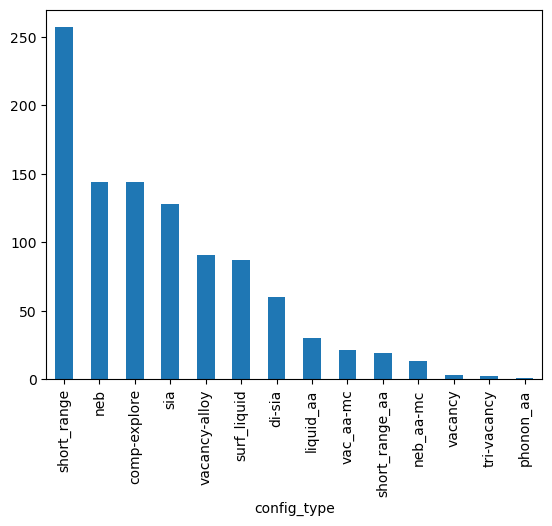

In [17]:
import matplotlib.pyplot as plt
# make a bar chart with config_type on the x-axis and frequency on the y-axis for how many structures of each config_type are in the top 100 hardest
top_100_hardest = analyser.df_struct.sort_values("MoranI", ascending=False).head(1000)
structure_ids = top_100_hardest['structure_id'].tolist()
metadata_map = db.get_structure_metadata_batch(structure_ids)
config_type_map = {sid: meta.get('config_type') for sid, meta in metadata_map.items()}
top_100_hardest['config_type'] = top_100_hardest['structure_id'].map(config_type_map)
config_type_counts = top_100_hardest['config_type'].value_counts()
config_type_counts.plot(kind='bar')
plt.show()

### Make a Report

In [22]:
struct_rank = 6
id_test = 29949
# Let's pick the ID of the top most difficult structure
worst_id = int(hardest_structures.iloc[struct_rank]["structure_id"])
print(f"--- Generating Report for Structure ID: {worst_id} ---")

report = analyser.generate_report(worst_id)
print(report)

--- Generating Report for Structure ID: 22112 ---

ANALYSIS REPORT FOR STRUCTURE ID: 22112
Formula: Cr121 (121 atoms)
Config Type: sia

* Key Metrics:
  - Difficulty Score: 3.94
  - Force RMSE:       0.2266 eV/Å
  - Kurtosis:         5.28 (Normal=3.0)
  - Gini Coefficient: 0.55 (0=perfect equality)
  - Moran's I:        0.51 (Positive = clustered errors)

* Hypothesis: 'Errors are driven by a few problematic atoms'
  - Hypothesis supported: YES. High Kurtosis (5.28) and Gini coefficient (0.55) suggest force errors are concentrated on a small number of 'problematic' atoms.
Furthermore, a significant Moran's I (0.51) indicates these atoms are spatially clustered.

* Spatial Hotspot Analysis:
  - No significant error clusters found.

* Top 5 Most Problematic Atoms (by |ΔF|):
  - Atom Index: 0, Symbol: Cr, Force Error: 0.650 eV/Å
  - Atom Index: 109, Symbol: Cr, Force Error: 0.649 eV/Å
  - Atom Index: 119, Symbol: Cr, Force Error: 0.638 eV/Å
  - Atom Index: 2, Symbol: Cr, Force Error: 0.63

In [32]:
# Get the Q95 threshold for this specific structure from the cache
print(analyser.results_cache[worst_id].keys())
q95_threshold = analyser.results_cache[worst_id]['force_stats']['Q95']

dict_keys(['atoms', 'force_error_magnitudes', 'spatial_stats', 'dbscan_labels', 'force_stats'])


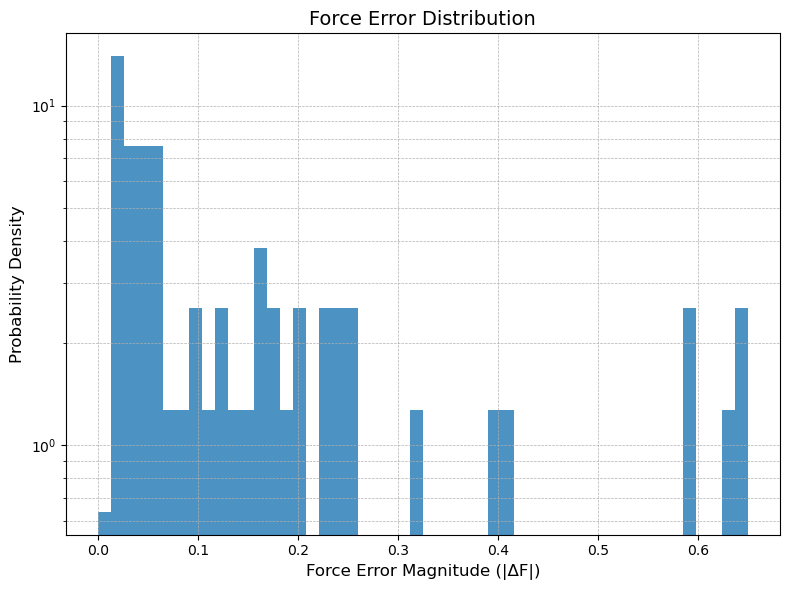

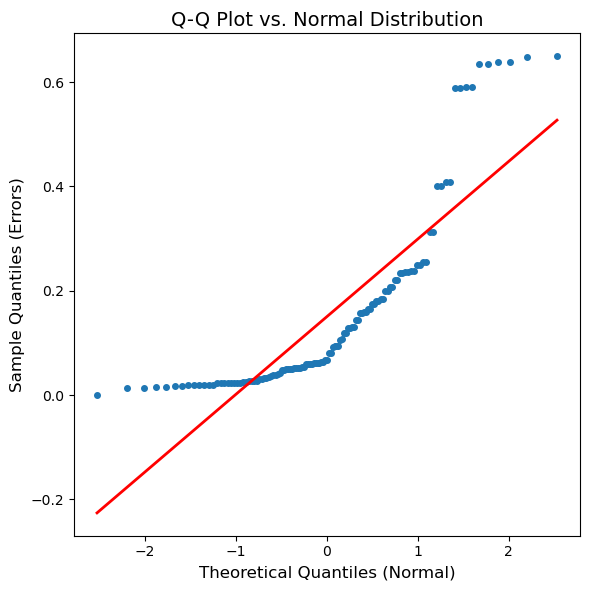

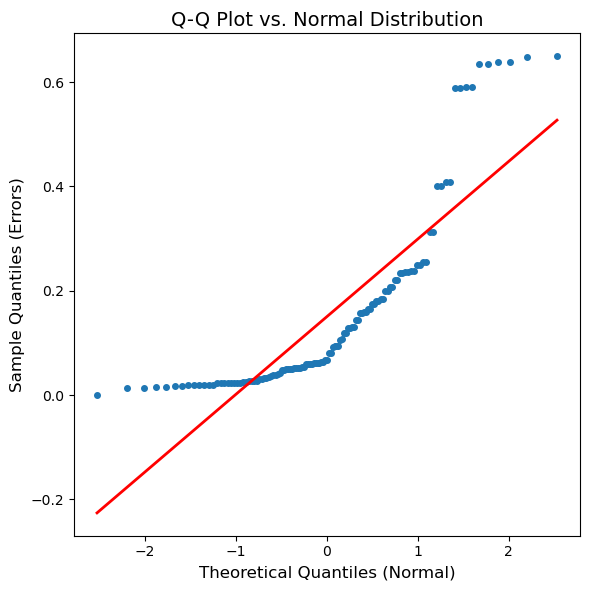

In [21]:
# Plot a histogram of the force errors
analyser.force_hist(worst_id, use_log_scale=True)

# Create a Q-Q plot to visually check for a heavy tail vs 
# a normal distribution
analyser.qq_plot(worst_id)

## Export to XYZ

In [2]:
from forge.analysis.training import ErrorAnalyser, load_analysis_from_pickle

# --- User Configuration ---
# 1. Set the path to the directory where your analysis results are saved.
analysis_dir = '../data/gen_8_analysis_recomputed_ovito'

# 2. Set the desired path for the output .extxyz file.
output_xyz_path = '../data/gen_8_analysis_recomputed_ovito/analysis_output_for_ovito.extxyz'
# --------------------------

# Load the saved analysis data from the pickle files.
print(f"Loading analysis from: {analysis_dir}")
df_struct, df_atom, results_cache = load_analysis_from_pickle(analysis_dir)

# Create a temporary ErrorAnalyser instance to hold the data.
# We don't need a database or calculators for this operation.
analyser = ErrorAnalyser(db_manager=None, calculators=None)

# Populate the analyser with the loaded data.
analyser.df_struct = df_struct
analyser.df_atom = df_atom
analyser.results_cache = results_cache

# Save the enriched data to a single .extxyz file for visualization in Ovito.
print(f"\nSaving data to: {output_xyz_path}")
analyser.save_to_extxyz(output_xyz_path)

print("\nProcess complete. You can now open the .extxyz file in Ovito.")

Loading analysis from: ../data/gen_8_analysis_recomputed_ovito
Successfully loaded analysis data from: /home/myless/Packages/Forge-Allegro-Test/forge/scratch/data/gen_8_analysis_recomputed_ovito

Saving data to: ../data/gen_8_analysis_recomputed_ovito/analysis_output_for_ovito.extxyz


Preparing .extxyz:   0%|          | 0/26791 [00:00<?, ?it/s]

Writing 26791 structures to ../data/gen_8_analysis_recomputed_ovito/analysis_output_for_ovito.extxyz...
Done.

Process complete. You can now open the .extxyz file in Ovito.
